In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma
import os
from reliability.Fitters import Fit_Weibull_2P
from lifelines import KaplanMeierFitter


In [2]:
df = pd.read_csv(
        "reliability_dataset1.csv")
        
df.to_csv(
    "reliability_dataset1.csv",
    index=False)




print(
    os.listdir())

['data_generation.ipynb', 'reliability_analysis.ipynb', 'reliability_dataset.csv', 'reliability_dataset1.csv']


In [3]:
def fit_groups(df):

    results = [] 
   
    groups = df.groupby(                              
        ["Test_Type",
         "Stress_Temperature_C",
         "Stress_Voltage_V",
         "Humidity_Percent"]
    )

    for (test_name, temp, voltage, humidity), group_data in groups:

        failures = group_data.loc[
            group_data["Censored"] == 0,
            "Failure_Time_Hours"
        ].values

        censored = group_data.loc[
            group_data["Censored"] == 1,
            "Failure_Time_Hours"
        ].values

        if len(failures) < 5:
            continue

        weibull_fit = Fit_Weibull_2P(
            failures=failures,
            right_censored=censored,
            show_probability_plot=False,
            print_results=False
        )

        result_table = weibull_fit.results

        eta = float(
            result_table.loc[
                result_table["Parameter"] == "Alpha",
                "Point Estimate"
            ].values[0]
        )

        beta = float(
            result_table.loc[
                result_table["Parameter"] == "Beta",
                "Point Estimate"
            ].values[0]
        )

        mttf = eta * gamma(1 + 1 / beta)

        if beta < 0.9:
            hazard = "Decreasing"

        elif beta <= 1.1:
            hazard = "Constant"

        else:
            hazard = "Increasing"

        summary = {
            "Test_Type": test_name,
            "Temp_C": temp,
            "Volt_V": voltage,
            "Humidity_%": humidity,

            "Total_Devices": len(group_data),
            "Failed_Devices": len(failures),
            "Censored_Devices": len(censored),

            "Beta": beta,
            "Eta": eta,
            "MTTF": mttf,

            "Hazard": hazard
        }

        results.append(summary)

    # Final report table
    final_report = pd.DataFrame(results)

    return final_report

result = fit_groups(df)

print(result)

   Test_Type  Temp_C  Volt_V  Humidity_%  ...    Beta     Eta    MTTF      Hazard
0       HTOL     100       4          40  ... 2.11599 1962.53 1738.13  Increasing
1       HTOL     100     4.5          40  ... 2.21341 1809.93 1602.96  Increasing
2       HTOL     100       5          40  ... 2.18951 1725.35    1528  Increasing
3       HTOL     125       4          40  ... 2.04061 800.545  709.24  Increasing
4       HTOL     125     4.5          40  ... 2.11489 762.254 675.095  Increasing
5       HTOL     125       5          40  ... 2.16711 718.624 636.416  Increasing
6       HTOL     150       4          40  ... 2.15721 371.923 329.377  Increasing
7       HTOL     150     4.5          40  ... 2.13481 341.269 302.236  Increasing
8       HTOL     150       5          40  ... 2.10669 323.045 286.113  Increasing
9         TC     -40       0          40  ... 1.74571 882.655  786.22  Increasing
10        TC     125       0          40  ... 1.78572 903.189 803.512  Increasing
11       THB    

In [4]:
result[
    result["Test_Type"] == "THB"
].sort_values(
    "Humidity_%"
)

,Test_Type,Temp_C,Volt_V,Humidity_%,...,Beta,Eta,MTTF,Hazard
11,THB,85,3.3,40,...,1.71059,4272.26,3810.31,Increasing
12,THB,85,3.3,60,...,2.03651,2866.75,2539.85,Increasing
13,THB,85,3.3,80,...,1.91115,2332.54,2069.43,Increasing


## Kaplan Meier Survival Analysis

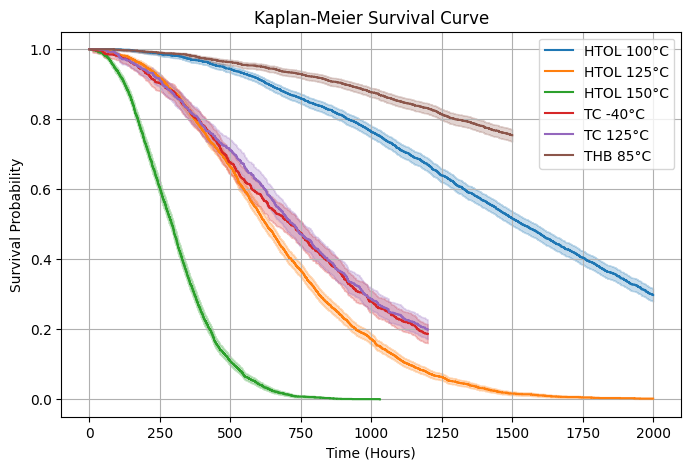

In [5]:
def plot_survival_curve(df):

    km = KaplanMeierFitter()

    plt.figure(figsize=(8, 5))

    groups = df.groupby(
        [
            "Test_Type",
            "Stress_Temperature_C"
        ]
    )

    for (test_type, temp), group_data in groups:

        survival_time = group_data[
            "Failure_Time_Hours"
        ]

        event_data = (
            1 - group_data["Censored"]
        )

        label_name = (
            str(test_type)
            + " "
            + str(temp)
            + "°C"
        )

        km.fit(
            durations=survival_time,
            event_observed=event_data,
            label=label_name
        )

        km.plot()

    plt.title(
        "Kaplan-Meier Survival Curve"
    )

    plt.xlabel(
        "Time (Hours)"
    )

    plt.ylabel(
        "Survival Probability"
    )

    plt.grid(True)

    plt.show()

plot_survival_curve(df)



## Weibull Probability Plot

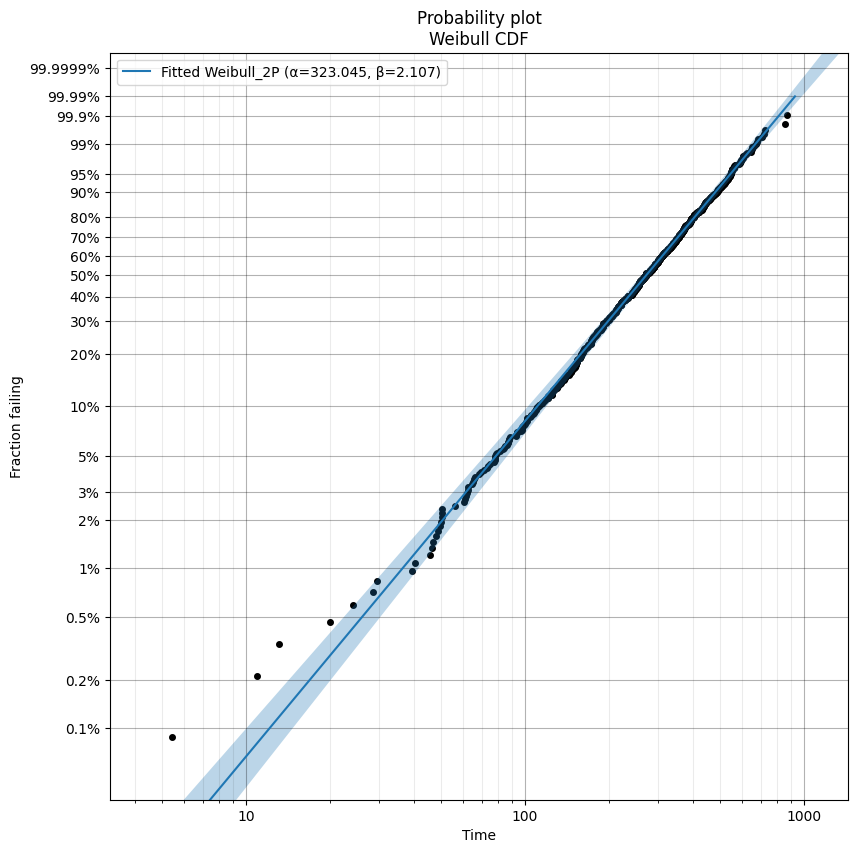

In [6]:
def show_weibull_probability_plot(df):

    selected_data = df[
        (df["Test_Type"]=="HTOL")
        &
        (df["Stress_Temperature_C"]==150)
        &
        (df["Stress_Voltage_V"]==5.0)
    ]

    failures = selected_data.loc[
        selected_data["Censored"]==0,
        "Failure_Time_Hours"
    ].values

    censored = selected_data.loc[
        selected_data["Censored"]==1,
        "Failure_Time_Hours"
    ].values

    Fit_Weibull_2P(
        failures=failures,
        right_censored=censored,
        show_probability_plot=True,
        print_results=False
    )

    plt.show()

show_weibull_probability_plot(df)




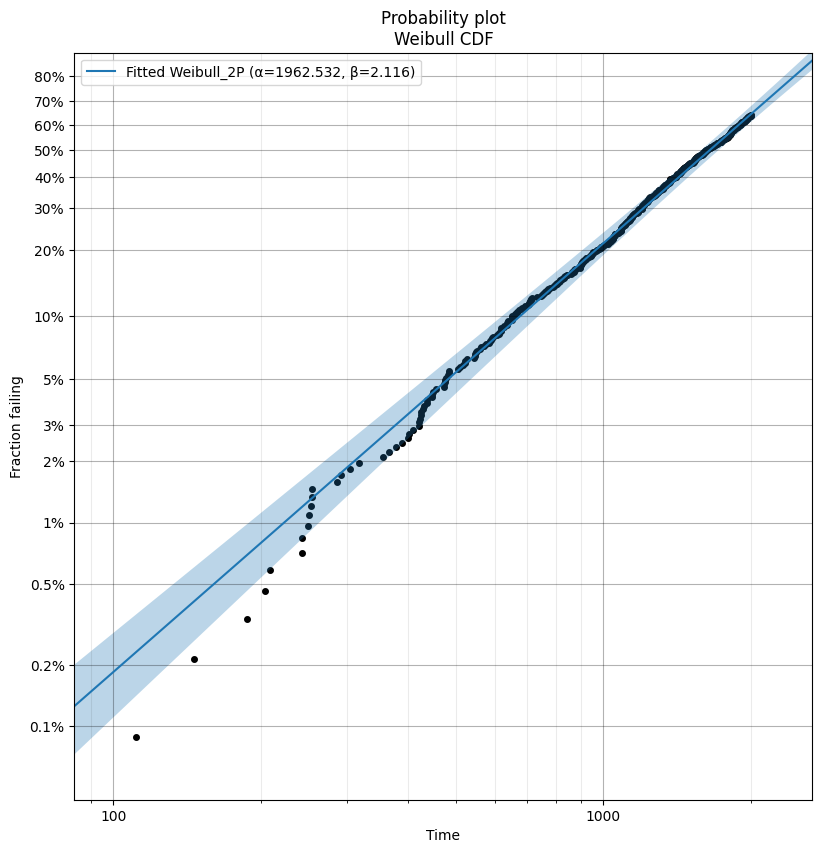

In [7]:
def show_weibull_probability_plot(df):

    selected_data = df[
        (df["Test_Type"]=="HTOL")
        &
        (df["Stress_Temperature_C"]==100)
        &
        (df["Stress_Voltage_V"]==4)
    ]

    failures = selected_data.loc[
        selected_data["Censored"]==0,
        "Failure_Time_Hours"
    ].values

    censored = selected_data.loc[
        selected_data["Censored"]==1,
        "Failure_Time_Hours"
    ].values

    Fit_Weibull_2P(
        failures=failures,
        right_censored=censored,
        show_probability_plot=True,
        print_results=False
    )

    plt.show()

show_weibull_probability_plot(df)

##The generated dataset intentionally incorporates batch-to-batch and device-to-device variability. Consequently, Weibull probability plots exhibit moderate deviations from ideal linear behavior, particularly in the low-failure-probability region, closely resembling practical semiconductor reliability datasets.

## Beta Vs Temperature

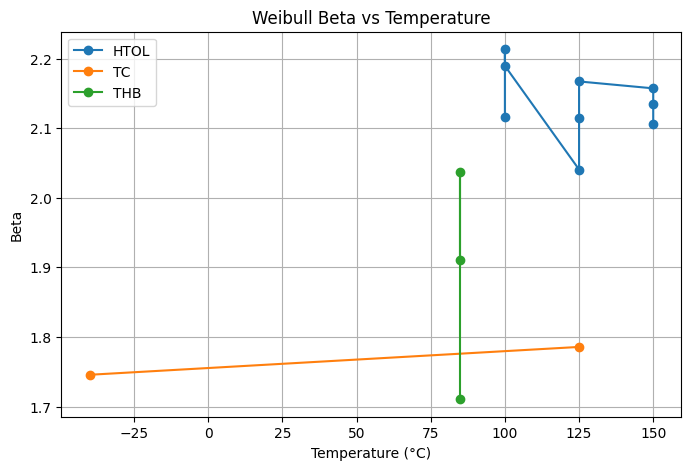

In [8]:
def plot_beta_vs_temperature(result):

    plt.figure(figsize=(8,5))

    groups = result.groupby(
        "Test_Type"
    )

    for test_type, group_data in groups:

        plt.plot(
            group_data["Temp_C"],
            group_data["Beta"],

            marker="o",

            label=test_type
        )

    plt.title(
        "Weibull Beta vs Temperature"
    )

    plt.xlabel(
        "Temperature (°C)"
    )

    plt.ylabel(
        "Beta"
    )

    plt.grid(True)

    plt.legend()

    plt.show()


plot_beta_vs_temperature(result)


## Eta vs Temperature

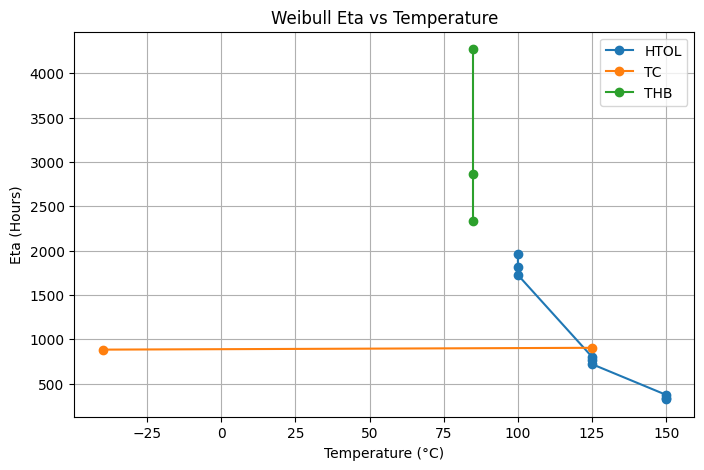

In [11]:

def plot_eta_vs_temperature(result):

    plt.figure(figsize=(8,5))

    groups = result.groupby(
        "Test_Type"
    )

    for test_type, group_data in groups:

        plt.plot(
            group_data["Temp_C"],
            group_data["Eta"],

            marker="o",

            label=test_type
        )

    plt.title(
        "Weibull Eta vs Temperature"
    )

    plt.xlabel(
        "Temperature (°C)"
    )

    plt.ylabel(
        "Eta (Hours)"
    )

    plt.grid(True)

    plt.legend()

    plt.show()
plot_eta_vs_temperature(result)





## Arrhenius_analysis

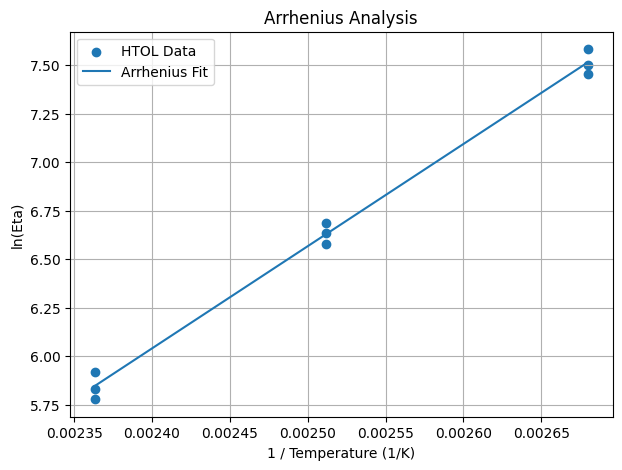


Intercept = -6.60768005068207
Slope = 5269.695221634113


In [10]:
def plot_arrhenius_analysis(result_table):


    htol_data = result_table[
        result_table["Test_Type"] == "HTOL"
    ].copy()

    htol_data["Temp_K"] = (
        htol_data["Temp_C"]
        + 273.15
    )

    inverse_temperature = (
        1 / htol_data["Temp_K"]
    )


    log_eta = np.log(
        htol_data["Eta"]
    )


    coefficients = np.polyfit(
        inverse_temperature,
        log_eta,
        1
    )

    slope = coefficients[0]

    intercept = coefficients[1]

    x_fit = np.linspace(
        inverse_temperature.min(),
        inverse_temperature.max(),
        100
    )

    y_fit = (
        slope * x_fit
        + intercept
    )

    plt.figure(figsize=(7,5))

    plt.scatter(
        inverse_temperature,
        log_eta,
        label="HTOL Data"
    )

    plt.plot(
        x_fit,
        y_fit,
        label="Arrhenius Fit"
    )

    plt.title(
        "Arrhenius Analysis"
    )

    plt.xlabel(
        "1 / Temperature (1/K)"
    )

    plt.ylabel(
        "ln(Eta)"
    )

    plt.grid(True)

    plt.legend()

    plt.show()

    # Physics result
    print()

    print("Intercept =", intercept)

    print("Slope =", slope)
result = fit_groups(df)
plot_arrhenius_analysis(result)
